In [14]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MultiLabelBinarizer,  StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
tqdm.pandas(desc="Processing Rows")
import os

import gc
import time
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
import ast
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import SGDClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    r2_score
)
from sklearn.ensemble import ExtraTreesClassifier

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
hf_token = "os.environ['HF_TOKEN']" 

### Load in Model

In [2]:
model_id = "/common/data/models/meta-llama--Llama-3.2-3B"
from transformers import AutoTokenizer, AutoModelForCausalLM

hf_token = "os.environ['HF_TOKEN']" 

tokenizer = AutoTokenizer.from_pretrained(model_id,token=hf_token)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    token=hf_token
)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 254/254 [00:00<00:00, 308.54it/s]


### Data Reading and formatting

In [16]:

df=pd.read_csv("../Datasets/World_Ecological_2015_Metadata.csv")
df
columns = [
    'geonameid', 'name', 'asciiname', 'alternatenames', 
    'latitude', 'longitude', 'feature_class', 'feature_code', 
    'country_code', 'cc2', 'admin1', 'admin2', 'admin3', 'admin4', 
    'population', 'elevation', 'dem', 'timezone', 'modification_date'
]

df_geo = pd.read_csv('../Datasets/allCountries.txt', sep='\t', names=columns, low_memory=False)
df_geo
df_landforms = df_geo[df_geo['feature_class'] == 'T']
combined_dataset=pd.read_csv("../Datasets/Global_Named_Landforms_With_Labels.csv")
combined_dataset=combined_dataset[['name','alternatenames','feature_code','ELU_LF_Des']]
combined_dataset

/localscratch/496762/ipykernel_3582544/2963070773.py:13: DtypeWarning: Columns (9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  combined_dataset=pd.read_csv("../Datasets/Global_Named_Landforms_With_Labels.csv")


,name,alternatenames,feature_code,ELU_LF_Des
0,Roc Meler,"Roc Mele,Roc Meler,Roc Mélé",PK,Mountains
1,Pic de les Abelletes,"Pic de la Font-Negre,Pic de la Font-Nègre,Pic de les Abelletes",PK,Mountains
2,Pic de Meners,NaN,PK,Mountains
3,Port de la Cabanette,"Port de la Cabanette,Porteille de la Cabanette",PASS,Mountains
4,Roc de Port Dret,NaN,PK,Mountains
...,...,...,...,...
1834956,Liverpool Bars,NaN,BAR,NaN
1834957,Doumeira Islands,Doumeira Islands,ISLS,NaN
1834958,Loaita Bank,"Bai Loai Ta,Bãi Loại Ta,Daoming Qunjiao,Loaita Bank,Luowan Dao,Nan-yueh T'ao,Nan-yüeh T’ao,Tao-ming Ch'un-chiao,Tao-ming Ch’un-chiao,dao ming qun jiao,luo wan dao,羅灣島,道明群礁",ATOL,NaN
1834959,Discovery Small Reef,"Burgos Reef,Da Nho,Discovery Small Reef,Dongnan Jiao,Hsiao-yen Chiao,Petit Recif Discovery,Petit Récif Discovery,Xiaofaxian Jiao,Xiaoxian Jiao,dong nan jiao,xiao fa xian jiao,xiao xian jiao,Đá Nhỏ,东南角,小现礁,小現礁,小發現礁",ATOL,NaN


In [18]:
exact_6_class_map = {
    # 1: Plains
    'PLN': 1, 'PLNS': 1, 'FLT': 1, 'PANS': 1,
    
    # 2: Hills and Low Tablelands
    'HLL': 2, 'HLLS': 2, 'MND': 2, 'KNOB': 2,
    
    # 3: High Tablelands
    'PT': 3, 'PLAT': 3, 'MESA': 3, 'BUTT': 3,
    
    # 4: Mountains
    'RDG': 4, 'RDGS': 4, 'SADL': 4, 'DUNE': 4,
    
    # 5: Widely Spaced Mountains
    'MT': 5, 'MTS': 5, 'PK': 5, 'PKS': 5, 'CONE': 5, 'VOLC': 5, 'NUP': 5, 'RK': 5,
    
    # 7: Depressions or Basins
    'BSN': 7, 'BSNS': 7, 'DPR': 7, 'SINK': 7, 'CRQS': 7, 'CRATER': 7
}

combined_dataset['macro_class_id'] = combined_dataset['feature_code'].map(exact_6_class_map)
combined_dataset = combined_dataset.dropna(subset=['macro_class_id'])
# combined_dataset['macro_class_id'] = combined_dataset['macro_class_id'].astype(int)
combined_dataset

/localscratch/496762/ipykernel_3582544/2645453257.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_dataset['macro_class_id'] = combined_dataset['feature_code'].map(exact_6_class_map)


,name,alternatenames,feature_code,ELU_LF_Des,macro_class_id
0,Roc Meler,"Roc Mele,Roc Meler,Roc Mélé",PK,Mountains,5
1,Pic de les Abelletes,"Pic de la Font-Negre,Pic de la Font-Nègre,Pic de les Abelletes",PK,Mountains,5
2,Pic de Meners,NaN,PK,Mountains,5
4,Roc de Port Dret,NaN,PK,Mountains,5
6,Roc del Xeig,NaN,RK,Mountains,5
...,...,...,...,...,...
1834929,South Rock,"Danzhu,Danzhu Shi,Danzhushi,South Rock,Tan-chu Shih,dan zhu,dan zhu shi,单柱,单柱石",RK,NaN,5
1834942,Whale Rock (historical),NaN,RK,NaN,5
1834949,Echo Point - Three Sisters,NaN,MT,NaN,5
1834953,Ipil Hill,"Ipil Hill,Ipil Seamount",HLL,NaN,2


In [21]:
combined_dataset.groupby(['feature_code', 'ELU_LF_Des']).size().reset_index(
    name='count'
)

,feature_code,ELU_LF_Des,count
0,CONE,Hills,62
1,CONE,Mountains,214
2,CONE,Plains,8
3,CONE,Surface Water,1
4,CRQS,Mountains,1
...,...,...,...
59,RK,Plains,1696
60,RK,Surface Water,1860
61,SINK,Hills,39
62,SINK,Mountains,290


In [22]:
combined_dataset.groupby(['feature_code']).size().reset_index(
    name='count'
)

,feature_code,count
0,CONE,401
1,CRQS,5
2,DPR,14501
3,DUNE,9809
4,HLL,502511
5,HLLS,23870
6,MESA,7018
7,MND,2670
8,MT,423139
9,MTS,29628


In [26]:
combined_dataset=combined_dataset[~combined_dataset['macro_class_id'].isna()]
combined_dataset=combined_dataset[['name','macro_class_id']]
combined_dataset.columns=['Bridges Full Name','Topographic']
combined_dataset = combined_dataset.groupby('Bridges Full Name')['Topographic'].apply(lambda x: list(set(x))).reset_index()
ascii_mask = combined_dataset['Bridges Full Name'].astype(str).str.contains(r'^[\x00-\x7F]+$')
combined_dataset = combined_dataset[ascii_mask].reset_index(drop=True)
combined_dataset

,Bridges Full Name,Topographic
0,'Adade Yus Mountain,[5]
1,'Aqabat Nikid,[5]
2,'Elb Chouf,[4]
3,'Elb ech Chaoufa,[4]
4,'S Airde Beinn,[2]
...,...,...
618599,wzgorze na Katarynkach,[2]
618600,wzgorze nad Tuchlinkiem,[2]
618601,yak Gawa,[5]
618602,ytre Midtberget,[2]


### Test Train split

In [27]:
def label_to_list(x):
    if isinstance(x, np.ndarray):
        return [int(v) for v in x.tolist()]

    if isinstance(x, (list, tuple)):
        return [int(v) for v in x]

    if isinstance(x, str):
        x = x.strip()
        if x.startswith("["):
            return [int(v) for v in ast.literal_eval(x)]
        return [int(float(x))]

    return [int(x)]


X = combined_dataset["Bridges Full Name"].astype(str)
y_labels = combined_dataset["Topographic"].apply(label_to_list)

# optional: stratify by exact label-combination string
y_combo = y_labels.apply(lambda z: tuple(sorted(z)))

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X,
    y_labels,
    test_size=0.20,
    stratify=None,
    random_state=42
)
MAX_TRAIN = 100000
MAX_TEST = 20000

train_combo = y_train_full.apply(lambda z: tuple(sorted(z)))
test_combo = y_test_full.apply(lambda z: tuple(sorted(z)))

X_train_list, _, y_train_labels, _ = train_test_split(
    X_train_full.tolist(),
    y_train_full.tolist(),
    train_size=min(MAX_TRAIN, len(X_train_full)),
    stratify=None,
    random_state=42
)

X_test_list, _, y_test_labels, _ = train_test_split(
    X_test_full.tolist(),
    y_test_full.tolist(),
    train_size=min(MAX_TEST, len(X_test_full)),
    stratify=None,
    random_state=42
)

mlb = MultiLabelBinarizer()
Y_train = mlb.fit_transform(y_train_labels)
Y_test = mlb.transform(y_test_labels)

print("Classes:", mlb.classes_)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

Classes: [1 2 3 4 5 7]
Y_train shape: (100000, 6)
Y_test shape: (20000, 6)


In [28]:
print("\n" + "=" * 50)
print("PER-CLASS LABEL COUNTS")
print("=" * 50)

# Sum across rows to get count per class column
train_class_counts = Y_train.sum(axis=0)
test_class_counts = Y_test.sum(axis=0)

df_class_stats = pd.DataFrame({
    'Class': mlb.classes_,
    'Train Count': train_class_counts,
    'Train %': (train_class_counts / len(Y_train) * 100).round(2),
    'Test Count': test_class_counts,
    'Test %': (test_class_counts / len(Y_test) * 100).round(2)
})

print(df_class_stats.to_string(index=False))


PER-CLASS LABEL COUNTS
 Class  Train Count  Train %  Test Count  Test %
     1         2531     2.53         511    2.56
     2        42109    42.11        8470   42.35
     3        11261    11.26        2288   11.44
     4          839     0.84         138    0.69
     5        46260    46.26        9237   46.18
     7         1202     1.20         223    1.12


In [34]:
combined_dataset

,Bridges Full Name,Topographic
0,'Adade Yus Mountain,[5]
1,'Aqabat Nikid,[5]
2,'Elb Chouf,[4]
3,'Elb ech Chaoufa,[4]
4,'S Airde Beinn,[2]
...,...,...
618599,wzgorze na Katarynkach,[2]
618600,wzgorze nad Tuchlinkiem,[2]
618601,yak Gawa,[5]
618602,ytre Midtberget,[2]


In [50]:

exploded = combined_dataset[['Topographic', 'Bridges Full Name']].explode('Topographic')

# 2. Group by feature code to count and extract sample bridge names
stats = (
    exploded.groupby('Topographic')
    .agg(
        count=('Topographic', 'size'),
        sample_bridges=('Bridges Full Name', lambda x: " | ".join(x.dropna().astype(str).unique()[800:812]))
    )
    .reset_index()
    .rename(columns={'Topographic': 'feature_code'})
    .sort_values(by='count', ascending=False)
)

# Set full text display so bridge names don't get truncated
import pandas as pd
pd.set_option('display.max_colwidth', None)

(stats)

,feature_code,count,sample_bridges
4,5,287230,Adrar -n-Tinzla | Adrar -n-Tissiyyi | Adrar -n-Tizi Moult | Adrar -n-Zeka | Adrar Abarchane | Adrar Adafor | Adrar Adakhs | Adrar Adcharene | Adrar Adeboun | Adrar Adesnou | Adrar Adjerazraz | Adrar Adoumas
1,2,260234,Adra n-Talae | Adra-n-Ghaddou | Adraa Uul | Adraagiyn Bayan Ulaan | Adrantarat | Adrar | Adrar -n-Abba | Adrar -n-Bouminta | Adrar -n-Tanaline | Adrar -n-Wawchtaft | Adrar Abrares | Adrar Adaoudab
2,3,69232,Anahawan Point | Anajao Point | Anama Zaki | Anamano Saki | Anamur Burnu | Ananias Point | Ananngiarjuk Point | Ananokuchi-hana | Anaomaki Point | Anapoto | Anaputa Point | Anaqtalik Point
0,1,15429,Battle Creek Meadows | Battle Flat | Battle Park | Battle Spring Flat | Batts Meadow | Bay Bottom | Bayan Sayn | Bayan Tsagaan | Bayan Uhaagiyn Tal | Bayer Park | Baylor Park | Bayside Bottoms
5,7,7463,Buku Leja | Bulangiin Hooloy | Bulayq | Bulin Do | Buljovica | Bull Basin | Bull Run | Bull Run Basin | Bull Run Cove | Bullards Basin | Bulldog Hole | Bullhead Basin
3,4,5057,Buurderduinen | Buzi Khad | CAW Nature Reserve Dune and Swale Complex (Possible) | Caari | Cad-Caddey | Cammaara | Camperduin | Caraah Madoobe | Carisley | Caroole | Cat Harbor Dune and Swale Complex (Minor) | Cawl


In [11]:

torch.cuda.empty_cache()
BATCH_SIZE = 32
MAX_LEN = 64

num_blocks = len(model.model.layers)
print("Transformer blocks:", num_blocks)
HIDDEN_STATE_LAYERS = [i for i in range(0,num_blocks+1,4)]

print("Using hidden_state indices:", HIDDEN_STATE_LAYERS)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

model.eval()
model.config.use_cache = False

if hasattr(model, "gradient_checkpointing_disable"):
    model.gradient_checkpointing_disable()

train_loader = DataLoader(
    X_train_list,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    X_test_list,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)
# first extract layers
def extract_selected_token_states(loader, desc, hidden_state_layers):
    chunks = {l: [] for l in hidden_state_layers}

    with torch.inference_mode():
        for batch in tqdm(loader, desc=desc):
            inputs = tokenizer(
                list(batch),
                padding=True,
                truncation=True,
                max_length=MAX_LEN,
                return_tensors="pt"
            ).to(model.device)
            lengths = inputs["attention_mask"].sum(dim=1) - 1
            batch_idx = torch.arange(inputs["input_ids"].shape[0], device=model.device)

            with torch.inference_mode():
                outputs = model(
                    **inputs,
                    output_hidden_states=True,
                    use_cache=False
                )

            for l in hidden_state_layers:
                hs = outputs.hidden_states[l]
                tok_state = hs[batch_idx, lengths, :]
                chunks[l].append(tok_state.float().cpu().numpy().astype(np.float32))

            del inputs, outputs, lengths, batch_idx, tok_state
            gc.collect()

    return {l: np.vstack(chunks[l]) for l in hidden_state_layers}

start = time.perf_counter()

print("\nExtracting train hidden states...")
train_cache = extract_selected_token_states(train_loader, "Train", HIDDEN_STATE_LAYERS)

print("\nExtracting test hidden states...")
test_cache = extract_selected_token_states(test_loader, "Test", HIDDEN_STATE_LAYERS)

print(f"\nExtraction time: {(time.perf_counter() - start) / 60:.2f} min")

torch.cuda.empty_cache()
gc.collect()


acc_list = []
f1_list = []
precision_list = []
recall_list = []
r2_list = []

best_score = -1
best_layer = None
best_probe = None
best_pred = None

for hs_idx in HIDDEN_STATE_LAYERS:
    print(f"\n--- Linear probe on hidden_states[{hs_idx}] ---")

    Xtr = train_cache[hs_idx]
    Xte = test_cache[hs_idx]

    probe = make_pipeline(
        StandardScaler(),
        OneVsRestClassifier(
            SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=1e-4,
                max_iter=50,
                tol=1e-3,
                random_state=42,
                early_stopping=False,
                n_jobs=-1
            ),
            n_jobs=-1
        )
    )

    probe.fit(Xtr, Y_train)
    pred = probe.predict(Xte)
    
    acc = accuracy_score(Y_test, pred)
    f1 = f1_score(Y_test, pred, average="weighted", zero_division=0)
    precision = precision_score(Y_test, pred, average="weighted", zero_division=0)
    recall = recall_score(Y_test, pred, average="weighted", zero_division=0)
    r2 = r2_score(Y_test, pred)

    acc_list.append(acc)
    f1_list.append(f1)
    precision_list.append(precision)
    recall_list.append(recall)
    r2_list.append(r2)

    print(f"Accuracy:  {acc:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"R2:        {r2:.4f}")

    if f1 > best_score:
        best_score = f1
        best_layer = hs_idx
        best_probe = probe
        best_pred = pred.copy()
    gc.collect()

Transformer blocks: 28
Using hidden_state indices: [0, 4, 8, 12, 16, 20, 24, 28]

Extracting train hidden states...


Train: 100%|██████████| 3125/3125 [19:56<00:00,  2.61it/s]



Extracting test hidden states...


Test: 100%|██████████| 625/625 [03:59<00:00,  2.61it/s]



Extraction time: 24.02 min

--- Linear probe on hidden_states[0] ---


...

Accuracy:  0.5223
F1:        0.6452
Precision: 0.6530
Recall:    0.6386
R2:        0.0175

--- Linear probe on hidden_states[24] ---


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Accuracy:  0.5300
F1:        0.6506
Precision: 0.6599
Recall:    0.6429
R2:        -0.0046

--- Linear probe on hidden_states[28] ---


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Accuracy:  0.5256
F1:        0.6428
Precision: 0.6503
Recall:    0.6377
R2:        -0.0089


In [14]:

torch.cuda.empty_cache()
BATCH_SIZE = 32
MAX_LEN = 64

num_blocks = len(model.model.layers)
print("Transformer blocks:", num_blocks)
HIDDEN_STATE_LAYERS = [i for i in range(0,num_blocks+1,4)]

print("Using hidden_state indices:", HIDDEN_STATE_LAYERS)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

model.eval()
model.config.use_cache = False

if hasattr(model, "gradient_checkpointing_disable"):
    model.gradient_checkpointing_disable()

train_loader = DataLoader(
    X_train_list,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    X_test_list,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)
# first extract layers
def extract_selected_token_states(loader, desc, hidden_state_layers):
    chunks = {l: [] for l in hidden_state_layers}

    with torch.inference_mode():
        for batch in tqdm(loader, desc=desc):
            inputs = tokenizer(
                list(batch),
                padding=True,
                truncation=True,
                max_length=MAX_LEN,
                return_tensors="pt"
            ).to(model.device)
            lengths = inputs["attention_mask"].sum(dim=1) - 1
            batch_idx = torch.arange(inputs["input_ids"].shape[0], device=model.device)

            with torch.inference_mode():
                outputs = model(
                    **inputs,
                    output_hidden_states=True,
                    use_cache=False
                )

            for l in hidden_state_layers:
                hs = outputs.hidden_states[l]
                tok_state = hs[batch_idx, lengths, :]
                chunks[l].append(tok_state.float().cpu().numpy().astype(np.float32))

            del inputs, outputs, lengths, batch_idx, tok_state
            gc.collect()

    return {l: np.vstack(chunks[l]) for l in hidden_state_layers}

start = time.perf_counter()

print("\nExtracting train hidden states...")
train_cache = extract_selected_token_states(train_loader, "Train", HIDDEN_STATE_LAYERS)

print("\nExtracting test hidden states...")
test_cache = extract_selected_token_states(test_loader, "Test", HIDDEN_STATE_LAYERS)

print(f"\nExtraction time: {(time.perf_counter() - start) / 60:.2f} min")

torch.cuda.empty_cache()
gc.collect()


acc_list = []
f1_list = []
precision_list = []
recall_list = []
r2_list = []

best_score = -1
best_layer = None
best_probe = None
best_pred = None

for hs_idx in HIDDEN_STATE_LAYERS:
    print(f"\n--- Linear probe on hidden_states[{hs_idx}] ---")

    Xtr = train_cache[hs_idx]
    Xte = test_cache[hs_idx]

    probe = make_pipeline(
        OneVsRestClassifier(
            ExtraTreesClassifier(
                n_estimators=200,
                n_jobs=-1,
                random_state=42
            )
        )
    )

    probe.fit(Xtr, Y_train)
    pred = probe.predict(Xte)
    
    acc = accuracy_score(Y_test, pred)
    f1 = f1_score(Y_test, pred, average="weighted", zero_division=0)
    precision = precision_score(Y_test, pred, average="weighted", zero_division=0)
    recall = recall_score(Y_test, pred, average="weighted", zero_division=0)
    r2 = r2_score(Y_test, pred)

    acc_list.append(acc)
    f1_list.append(f1)
    precision_list.append(precision)
    recall_list.append(recall)
    r2_list.append(r2)

    print(f"Accuracy:  {acc:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"R2:        {r2:.4f}")

    if f1 > best_score:
        best_score = f1
        best_layer = hs_idx
        best_probe = probe
        best_pred = pred.copy()
    gc.collect()
# Save all lists into one text file
output_filename = "linear_probe_metrics_NL_llama3b.txt"

with open(output_filename, "w") as f:
    f.write(f"Layers:    {HIDDEN_STATE_LAYERS}\n")
    f.write(f"Accuracy:  {acc_list}\n")
    f.write(f"F1:        {f1_list}\n")
    f.write(f"Precision: {precision_list}\n")
    f.write(f"Recall:    {recall_list}\n")
    f.write(f"R2:        {r2_list}\n")

print(f"Metrics saved to {output_filename}")

Transformer blocks: 28
Using hidden_state indices: [0, 4, 8, 12, 16, 20, 24, 28]

Extracting train hidden states...


Train: 100%|██████████| 3125/3125 [29:27<00:00,  1.77it/s]



Extracting test hidden states...


Test: 100%|██████████| 625/625 [05:36<00:00,  1.86it/s]



Extraction time: 35.23 min

--- Linear probe on hidden_states[0] ---
Accuracy:  0.5139
F1:        0.5988
Precision: 0.6833
Recall:    0.5383
R2:        0.0902

--- Linear probe on hidden_states[4] ---
Accuracy:  0.4466
F1:        0.5737
Precision: 0.7769
Recall:    0.4672
R2:        0.1273

--- Linear probe on hidden_states[8] ---
Accuracy:  0.5088
F1:        0.6104
Precision: 0.7624
Recall:    0.5309
R2:        0.0816

--- Linear probe on hidden_states[12] ---
Accuracy:  0.5175
F1:        0.6234
Precision: 0.7697
Recall:    0.5420
R2:        0.1032

--- Linear probe on hidden_states[16] ---
Accuracy:  0.5795
F1:        0.6828
Precision: 0.7936
Recall:    0.6081
R2:        0.2272

--- Linear probe on hidden_states[20] ---
Accuracy:  0.5947
F1:        0.6919
Precision: 0.7915
Recall:    0.6227
R2:        0.2414

--- Linear probe on hidden_states[24] ---
Accuracy:  0.5941
F1:        0.6896
Precision: 0.7898
Recall:    0.6219
R2:        0.2240

--- Linear probe on hidden_states[28] ---
A

In [15]:
# import joblib

# joblib.dump(train_cache, "train_cache.pkl")
# joblib.dump(test_cache, "test_cache.pkl")
joblib.dump(best_probe, "best_nonl_probe.pkl")

# joblib.dump({
#     "best_layer": best_layer,
#     "Y_train": np.asarray(Y_train),
#     "Y_test": np.asarray(Y_test),
#     "classes": mlb.classes_
# }, "linear_probe_info.pkl")

print("Saved.")

Saved.


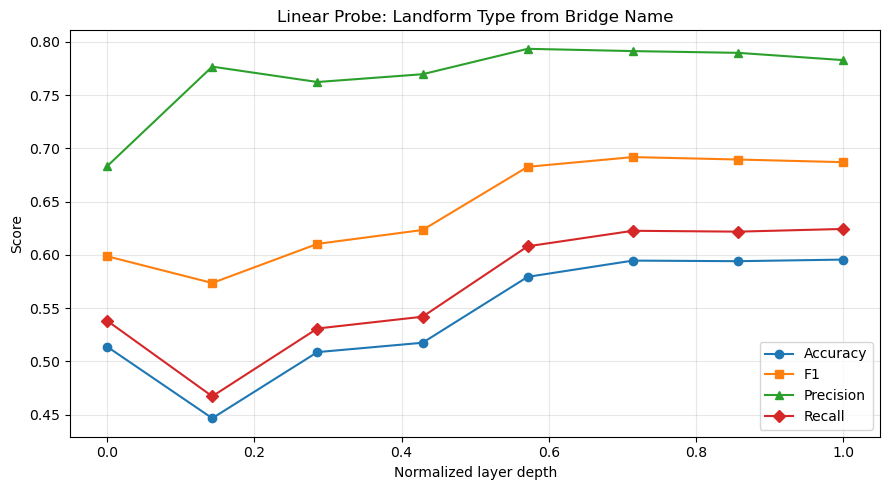

In [9]:
depth = np.array(HIDDEN_STATE_LAYERS) / num_blocks

plt.figure(figsize=(9, 5))

plt.plot(depth, acc_list, marker="o", label="Accuracy")
plt.plot(depth, f1_list, marker="s", label="F1")
plt.plot(depth, precision_list, marker="^", label="Precision")
plt.plot(depth, recall_list, marker="D", label="Recall")

plt.xlabel("Normalized layer depth")
plt.ylabel("Score")
plt.title("Linear Probe: Landform Type from Bridge Name")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# # Save all lists into one text file
# output_filename = "linear_probe_metrics_llama3b.txt"

# with open(output_filename, "w") as f:
#     f.write(f"Layers:    {HIDDEN_STATE_LAYERS}\n")
#     f.write(f"Accuracy:  {acc_list}\n")
#     f.write(f"F1:        {f1_list}\n")
#     f.write(f"Precision: {precision_list}\n")
#     f.write(f"Recall:    {recall_list}\n")
#     f.write(f"R2:        {r2_list}\n")

# print(f"Metrics saved to {output_filename}")